# ADAPT Map Comparison: GONG vs HMI-LOS

Downloads maps directly from `gong.nso.edu`, bypassing sunpy broken ADAPTClient.

```
pip install requests beautifulsoup4 astropy matplotlib numpy scipy
```

In [3]:
import re, os, gzip
from datetime import datetime, timedelta
from io import BytesIO

import requests
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from bs4 import BeautifulSoup
from astropy.io import fits
from scipy.interpolate import RectBivariateSpline

%matplotlib inline
plt.rcParams.update({'font.size': 11})

## 1. Configuration

In [4]:
YEAR        = 2025
TARGET_DATE = None  # e.g. '2025-06-15', or None for latest
REALIZATION = 0
CACHE_DIR   = 'adapt_cache'

GONG_BASE = 'https://gong.nso.edu/adapt/maps/gong'
HMI_BASE  = 'https://gong.nso.edu/adapt/maps/hmi-los'

## 2. Helper functions

In [5]:
ADAPT_RE = re.compile(
    r'(adapt'
    r'(?P<Z>\d)'
    r'(?P<X>\d)'
    r'(?P<A>\d)'
    r'(?P<B>\d)'
    r'(?P<R>\d)'
    r'_'
    r'(?P<CC>\d{2})'
    r'(?P<E>\w)'
    r'(?P<FFF>\d{3})'
    r'_'
    r'(?P<Y>\d{4})(?P<M>\d{2})(?P<D>\d{2})(?P<HH>\d{2})(?P<NN>\d{2})'
    r'_'
    r'(?P<T>[aifs])'
    r'(?P<II>\d{2})(?P<JJ>\d{2})(?P<KK>\d{2})(?P<LL>\d{2})'
    r'(?P<G>[nfeb])'
    r'(?P<Q>\d)'
    r'\.fts(?:\.gz)?)'
)

def list_adapt_files(base_url, year, lon_type='0'):
    url = base_url + '/' + str(year) + '/'
    print('  Listing:', url)
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, 'html.parser')
    results = []
    for link in soup.find_all('a'):
        href = link.get('href', '')
        m = ADAPT_RE.match(href)
        if m is None or m.group('X') != lon_type:
            continue
        dt = datetime(int(m.group('Y')), int(m.group('M')), int(m.group('D')),
                      int(m.group('HH')), int(m.group('NN')))
        results.append((dt, href, url + href))
    results.sort(key=lambda x: x[0])
    print('    Found', len(results), 'Carrington-fixed maps')
    return results

def find_common_times(gong_files, hmi_files, tol_hours=3):
    if not gong_files or not hmi_files:
        return []
    hmi_dts = np.array([e[0].timestamp() for e in hmi_files])
    pairs = []
    for g_entry in gong_files:
        idx = np.argmin(np.abs(hmi_dts - g_entry[0].timestamp()))
        if abs(hmi_dts[idx] - g_entry[0].timestamp()) / 3600 <= tol_hours:
            pairs.append((g_entry, hmi_files[idx]))
    return pairs

def download(url, cache_dir=CACHE_DIR):
    os.makedirs(cache_dir, exist_ok=True)
    fname = url.split('/')[-1]
    local = os.path.join(cache_dir, fname)
    if os.path.exists(local):
        print('    Cached:', fname)
        return local
    print('    Downloading:', fname)
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    with open(local, 'wb') as f:
        f.write(r.content)
    print('      Done (%.1f MB)' % (len(r.content)/1e6))
    return local

def load_adapt(filepath, realization=0):
    if filepath.endswith('.gz'):
        with gzip.open(filepath, 'rb') as gz:
            hdul = fits.open(BytesIO(gz.read()))
    else:
        hdul = fits.open(filepath)
    data = hdul[0].data.copy().astype(np.float64)
    hdr  = dict(hdul[0].header)
    hdul.close()
    if data.ndim == 3:
        print('      %d realizations, using #%d' % (data.shape[0], realization))
        data = data[realization]
    return data, hdr

def fname_info(fname):
    m = ADAPT_RE.match(fname)
    if not m:
        return {'raw': fname}
    src = {'0':'All','1':'KPVT','2':'VSM','3':'GONG','4':'HMI',
           '5':'FDT','7':'SVSM+FDT','8':'GONG+FDT','9':'HMI+FDT'}
    evol = {'a':'assimilation','i':'intermediate','f':'forecast','s':'seedmap'}
    return dict(
        source   = src.get(m.group('A'), '?'),
        version  = 'v%s.%s' % (m.group('CC'), m.group('E')),
        n_real   = int(m.group('FFF')),
        map_time = '%s-%s-%s %s:%s UT' % (m.group('Y'),m.group('M'),m.group('D'),m.group('HH'),m.group('NN')),
        evol     = evol.get(m.group('T'), m.group('T')),
        lag      = '%sd %sh %sm' % (m.group('II'),m.group('JJ'),m.group('KK')),
        res      = '1.0 deg' if m.group('R')=='1' else '0.2 deg',
    )

def make_axes(data, hdr):
    nlat, nlon = data.shape
    crval1 = hdr.get('CRVAL1', hdr.get('CRVAL1A'))
    cdelt1 = hdr.get('CDELT1', hdr.get('CDELT1A'))
    crpix1 = hdr.get('CRPIX1', hdr.get('CRPIX1A'))
    crval2 = hdr.get('CRVAL2', hdr.get('CRVAL2A'))
    cdelt2 = hdr.get('CDELT2', hdr.get('CDELT2A'))
    crpix2 = hdr.get('CRPIX2', hdr.get('CRPIX2A'))
    if all(v is not None for v in [crval1, cdelt1, crpix1]):
        lon = crval1 + (np.arange(nlon) + 1 - crpix1) * cdelt1
    else:
        lon = np.linspace(0, 360, nlon, endpoint=False)
    if all(v is not None for v in [crval2, cdelt2, crpix2]):
        lat = crval2 + (np.arange(nlat) + 1 - crpix2) * cdelt2
    else:
        sinlat = np.linspace(-1, 1, nlat)
        lat = np.degrees(np.arcsin(sinlat))
    return lon, lat

## 3. Search & download

In [6]:
print('[GONG]')
gong_files = list_adapt_files(GONG_BASE, YEAR)
print()
print('[HMI-LOS]')
hmi_files = list_adapt_files(HMI_BASE, YEAR)

pairs = find_common_times(gong_files, hmi_files, tol_hours=3)
print()
print(len(pairs), 'time-matched GONG/HMI pairs found')
if not pairs:
    raise RuntimeError('No matched pairs! Try a different YEAR.')

[GONG]
  Listing: https://gong.nso.edu/adapt/maps/gong/2025/
    Found 4380 Carrington-fixed maps

[HMI-LOS]
  Listing: https://gong.nso.edu/adapt/maps/hmi-los/2025/
    Found 728 Carrington-fixed maps

2183 time-matched GONG/HMI pairs found


In [7]:
if TARGET_DATE:
    target = datetime.strptime(TARGET_DATE, '%Y-%m-%d')
    best = min(range(len(pairs)),
               key=lambda i: abs((pairs[i][0][0] - target).total_seconds()))
else:
    best = -1

g_entry, h_entry = pairs[best]
print('GONG:', g_entry[1])
print('  time =', g_entry[0])
print('HMI: ', h_entry[1])
print('  time =', h_entry[0])
print('dt = %.1f hours' % (abs((g_entry[0]-h_entry[0]).total_seconds())/3600))

GONG: adapt40311_044012_202512312200_i00005600n1.fts.gz
  time = 2025-12-31 22:00:00
HMI:  adapt40411_043012_202512312000_i00030000n1.fts.gz
  time = 2025-12-31 20:00:00
dt = 2.0 hours


In [8]:
print('Downloading ...')
g_path = download(g_entry[2])
h_path = download(h_entry[2])

print()
print('Loading GONG ...')
gong_data, gong_hdr = load_adapt(g_path, REALIZATION)
gong_info = fname_info(g_entry[1])
print('  shape:', gong_data.shape, gong_info)

print()
print('Loading HMI ...')
hmi_data, hmi_hdr = load_adapt(h_path, REALIZATION)
hmi_info = fname_info(h_entry[1])
print('  shape:', hmi_data.shape, hmi_info)

    Downloading: adapt40311_044012_202512312200_i00005600n1.fts.gz
      Done (3.1 MB)
    Downloading: adapt40411_043012_202512312000_i00030000n1.fts.gz
      Done (3.1 MB)

Loading GONG ...
      12 realizations, using #0
  shape: (180, 360) {'source': 'GONG', 'version': 'v04.4', 'n_real': 12, 'map_time': '2025-12-31 22:00 UT', 'evol': 'intermediate', 'lag': '00d 00h 56m', 'res': '1.0 deg'}

Loading HMI ...
      12 realizations, using #0
  shape: (180, 360) {'source': 'HMI', 'version': 'v04.3', 'n_real': 12, 'map_time': '2025-12-31 20:00 UT', 'evol': 'intermediate', 'lag': '00d 03h 00m', 'res': '1.0 deg'}


## 4. Prepare grids & interpolation

In [9]:
lon_g, lat_g = make_axes(gong_data, gong_hdr)
lon_h, lat_h = make_axes(hmi_data, hmi_hdr)

vmax = max(np.nanpercentile(np.abs(gong_data), 99.5),
           np.nanpercentile(np.abs(hmi_data), 99.5))
if vmax == 0:
    vmax = 1.0
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

def sort_lat(lat, data):
    if lat[0] > lat[-1]:
        return lat[::-1], data[::-1]
    return lat.copy(), data.copy()

lat_g_s, gong_s = sort_lat(lat_g, gong_data)
lat_h_s, hmi_s  = sort_lat(lat_h, hmi_data)

interp = RectBivariateSpline(lat_h_s, lon_h, hmi_s)
hmi_on_g = interp(lat_g_s, lon_g)
diff = gong_s - hmi_on_g

print('GONG grid: %d x %d' % (len(lat_g), len(lon_g)))
print('HMI  grid: %d x %d' % (len(lat_h), len(lon_h)))
print('vmax = %.1f G' % vmax)

GONG grid: 180 x 360
HMI  grid: 180 x 360
vmax = 176.4 G


## 5. Six-panel comparison

Saved: adapt_gong_vs_hmi.png


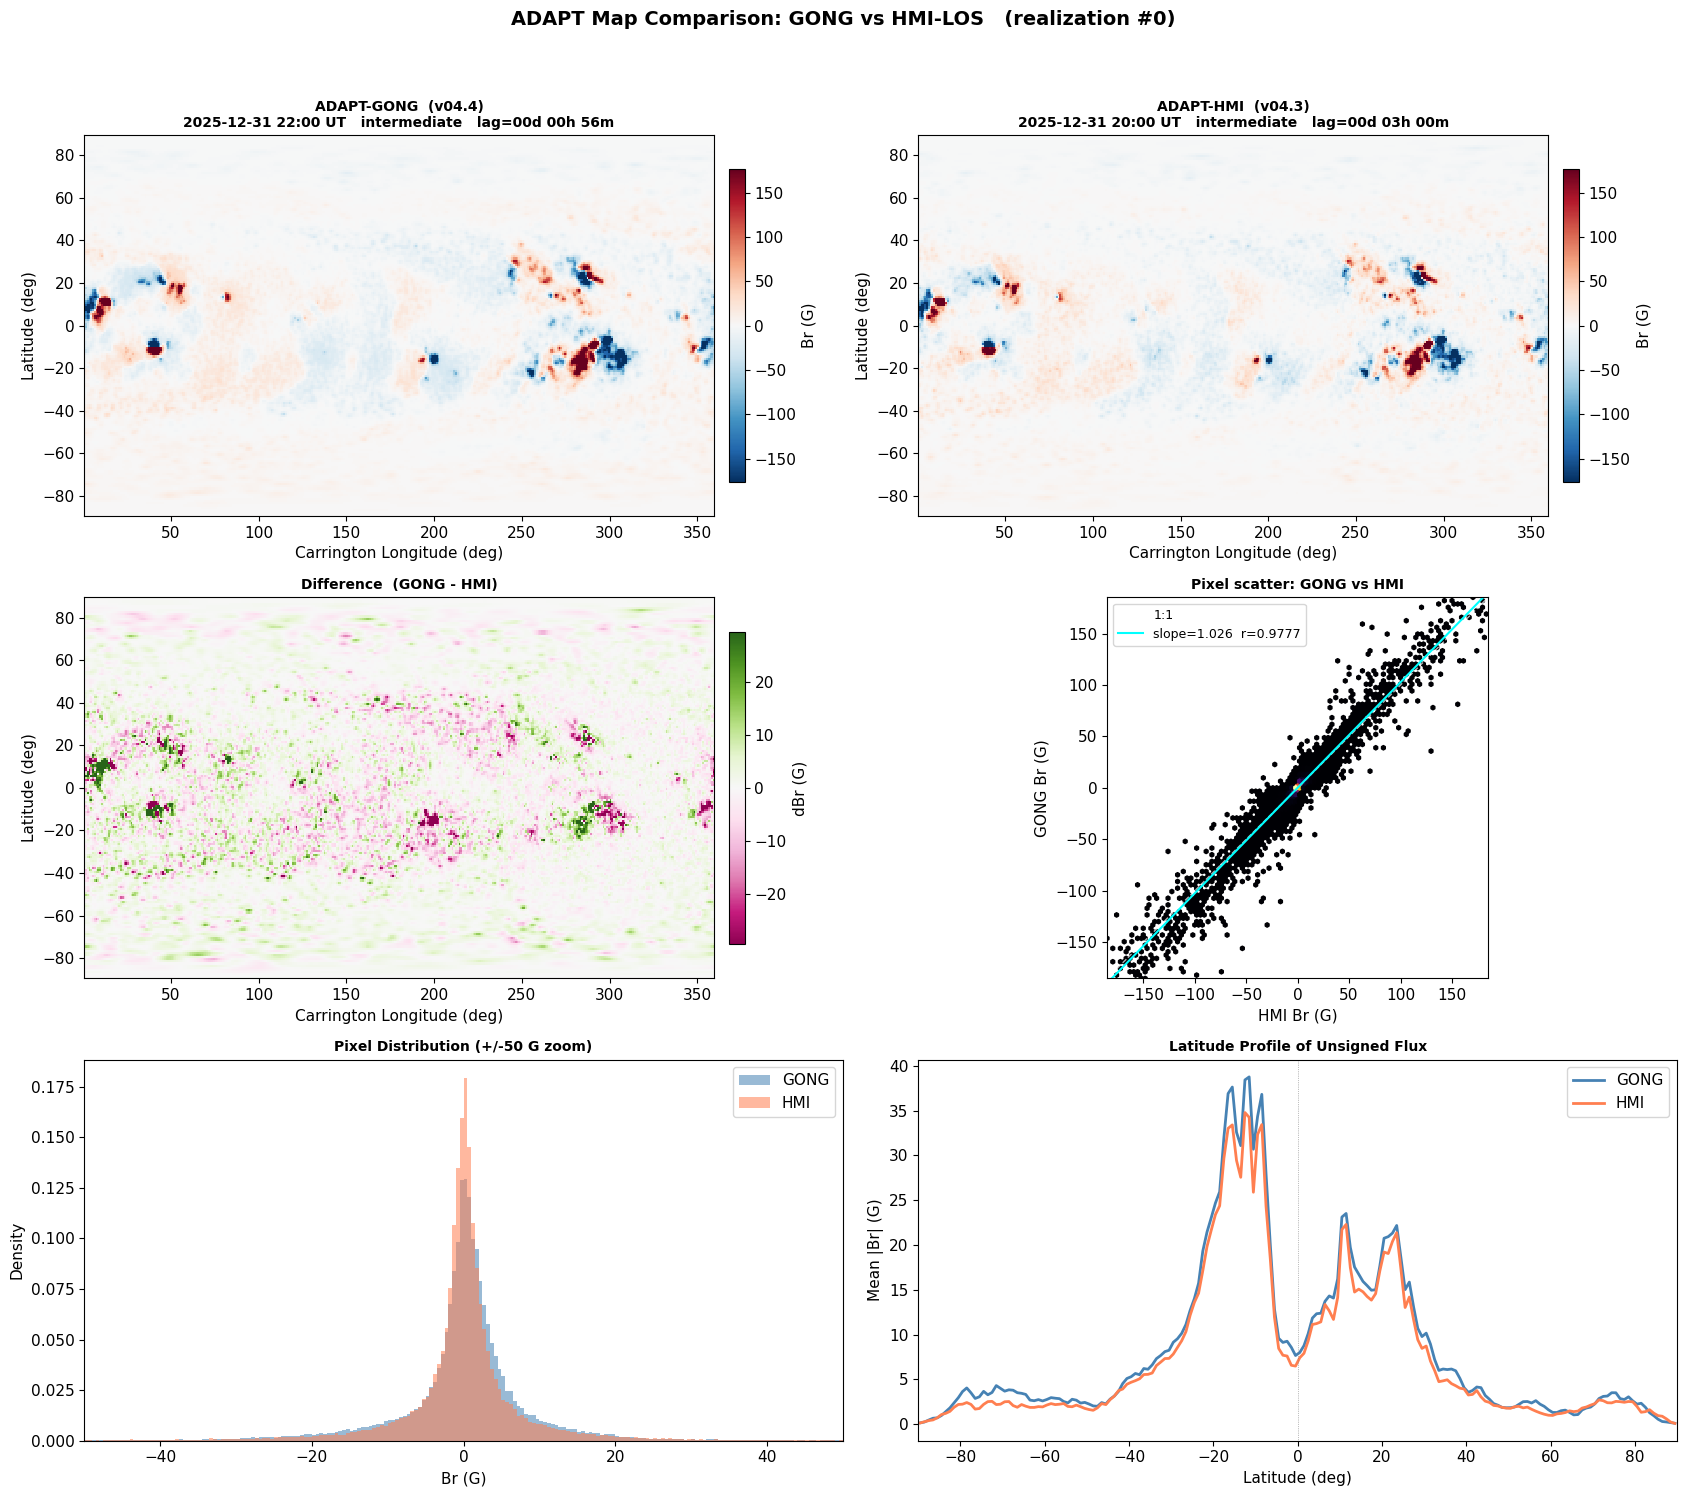

In [10]:
def make_label(info, tag):
    return (tag + '  (' + info.get('version','') + ')\n'
            + info.get('map_time','') + '   ' + info.get('evol','')
            + '   lag=' + info.get('lag',''))

fig, axes = plt.subplots(3, 2, figsize=(17, 15))
fig.patch.set_facecolor('white')

# Row 1: maps
for ax, dat, lon, lat, info, tag in [
    (axes[0,0], gong_data, lon_g, lat_g, gong_info, 'ADAPT-GONG'),
    (axes[0,1], hmi_data,  lon_h, lat_h, hmi_info,  'ADAPT-HMI'),
]:
    im = ax.pcolormesh(lon, lat, dat, cmap='RdBu_r', norm=norm,
                       shading='auto', rasterized=True)
    ax.set_title(make_label(info, tag), fontsize=10, fontweight='bold')
    ax.set_xlabel('Carrington Longitude (deg)')
    ax.set_ylabel('Latitude (deg)')
    ax.set_xlim(lon.min(), lon.max())
    ax.set_ylim(lat.min(), lat.max())
    plt.colorbar(im, ax=ax, label='Br (G)', shrink=0.82, pad=0.02)

# Row 2 left: difference
dv = np.nanpercentile(np.abs(diff), 99.5)
if dv == 0:
    dv = 1.0
dn = TwoSlopeNorm(vmin=-dv, vcenter=0, vmax=dv)

ax3 = axes[1, 0]
im3 = ax3.pcolormesh(lon_g, lat_g_s, diff, cmap='PiYG', norm=dn,
                     shading='auto', rasterized=True)
ax3.set_title('Difference  (GONG - HMI)', fontsize=10, fontweight='bold')
ax3.set_xlabel('Carrington Longitude (deg)')
ax3.set_ylabel('Latitude (deg)')
ax3.set_xlim(lon_g.min(), lon_g.max())
ax3.set_ylim(lat_g_s.min(), lat_g_s.max())
plt.colorbar(im3, ax=ax3, label='dBr (G)', shrink=0.82, pad=0.02)

# Row 2 right: scatter
ax4 = axes[1, 1]
step = max(1, gong_s.size // 60000)
gf = gong_s.ravel()[::step]
hf = hmi_on_g.ravel()[::step]
ok = np.isfinite(gf) & np.isfinite(hf)
gf, hf = gf[ok], hf[ok]

lim = vmax * 1.05
ax4.hexbin(hf, gf, gridsize=100, cmap='inferno', mincnt=1,
           extent=[-lim, lim, -lim, lim])
ax4.plot([-lim, lim], [-lim, lim], 'w--', lw=1, alpha=0.7, label='1:1')
if len(gf) > 10:
    c = np.polyfit(hf, gf, 1)
    r = np.corrcoef(hf, gf)[0, 1]
    ax4.plot([-lim, lim], np.polyval(c, [-lim, lim]), 'cyan', lw=1.5,
             label='slope=%.3f  r=%.4f' % (c[0], r))
ax4.set_xlabel('HMI Br (G)')
ax4.set_ylabel('GONG Br (G)')
ax4.set_title('Pixel scatter: GONG vs HMI', fontsize=10, fontweight='bold')
ax4.legend(fontsize=9, loc='upper left')
ax4.set_aspect('equal')
ax4.set_xlim(-lim, lim)
ax4.set_ylim(-lim, lim)

# Row 3 left: histogram
ax5 = axes[2, 0]
bins = np.linspace(-50, 50, 201)
ax5.hist(gong_data.ravel(), bins=bins, density=True, alpha=0.55,
         label='GONG', color='steelblue')
ax5.hist(hmi_data.ravel(), bins=bins, density=True, alpha=0.55,
         label='HMI', color='coral')
ax5.set_xlabel('Br (G)')
ax5.set_ylabel('Density')
ax5.set_title('Pixel Distribution (+/-50 G zoom)', fontsize=10, fontweight='bold')
ax5.legend()
ax5.set_xlim(-50, 50)

# Row 3 right: latitude profile
ax6 = axes[2, 1]
ax6.plot(lat_g_s, np.nanmean(np.abs(gong_s), axis=1),
         lw=2, color='steelblue', label='GONG')
ax6.plot(lat_g_s, np.nanmean(np.abs(hmi_on_g), axis=1),
         lw=2, color='coral', label='HMI')
ax6.set_xlabel('Latitude (deg)')
ax6.set_ylabel('Mean |Br| (G)')
ax6.set_title('Latitude Profile of Unsigned Flux', fontsize=10, fontweight='bold')
ax6.legend()
ax6.set_xlim(-90, 90)
ax6.axvline(0, color='gray', ls=':', lw=0.5)

fig.suptitle('ADAPT Map Comparison: GONG vs HMI-LOS   (realization #%d)' % REALIZATION,
             fontsize=14, fontweight='bold', y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig('adapt_gong_vs_hmi.png', dpi=180, bbox_inches='tight', facecolor='white')
print('Saved: adapt_gong_vs_hmi.png')
plt.show()

## 6. Quick statistics

In [11]:
print('%30s  %12s  %12s' % ('', 'GONG', 'HMI'))
print('-' * 58)
for name, func in [
    ('Mean Br (G)',           lambda d: np.nanmean(d)),
    ('Median |Br| (G)',       lambda d: np.nanmedian(np.abs(d))),
    ('Max |Br| (G)',          lambda d: np.nanmax(np.abs(d))),
    ('Std Br (G)',            lambda d: np.nanstd(d)),
    ('Total unsigned (G*px)', lambda d: np.nansum(np.abs(d))),
]:
    print('%30s  %12.3f  %12.3f' % (name, func(gong_data), func(hmi_data)))

if len(gf) > 10:
    print()
    print('%30s  %12.4f' % ('Slope (GONG vs HMI)', c[0]))
    print('%30s  %12.4f' % ('Pearson r', r))

                                        GONG           HMI
----------------------------------------------------------
                   Mean Br (G)         0.200         0.066
               Median |Br| (G)         2.791         2.098
                  Max |Br| (G)      1093.563      1098.086
                    Std Br (G)        29.322        27.949
         Total unsigned (G*px)    538650.954    476877.889

           Slope (GONG vs HMI)        1.0258
                     Pearson r        0.9777
